In [2]:
!pip install pymongo

  Using cached pymongo-4.17.0-cp312-cp312-win_amd64.whl.metadata (10 kB)
Using cached pymongo-4.17.0-cp312-cp312-win_amd64.whl (920 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Cell 1 — Imports:

In [3]:
import pandas as pd
import numpy as np
from pymongo import MongoClient
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

from dotenv import load_dotenv
load_dotenv("../.env")

MONGODB_URI = os.getenv("MONGODB_URI")
print("Imports done ✅")

Imports done ✅


### Cell 2 — Load data from MongoDB:

In [4]:
client = MongoClient(MONGODB_URI)
db     = client["pearls_aqi"]
data   = list(db["aqi_engineered"].find({}, {"_id": 0}))
client.close()

df = pd.DataFrame(data)
print(f"Loaded: {df.shape}")
df.head()

Loaded: (2160, 23)


,timestamp,date,hour,day,month,city,aqi,pm2_5,pm10,no2,...,humidity,wind_speed,aqi_lag_1,aqi_lag_3,aqi_lag_24,aqi_rolling_mean_24,aqi_change_rate,time_of_day,is_weekend,season
0,2026-02-24 00:00:00,2026-02-24,0,24,2,Sukkur,78,69.6,86.4,25.7,...,78,4.4,79.0,80.0,91.0,85.166667,-1.0,night,0,winter
1,2026-02-24 01:00:00,2026-02-24,1,24,2,Sukkur,78,69.6,88.9,27.8,...,81,5.7,78.0,80.0,91.0,84.625000,0.0,night,0,winter
2,2026-02-24 02:00:00,2026-02-24,2,24,2,Sukkur,78,75.4,95.7,30.5,...,84,6.1,78.0,79.0,90.0,84.083333,0.0,night,0,winter
3,2026-02-24 03:00:00,2026-02-24,3,24,2,Sukkur,78,86.6,107.3,30.0,...,78,6.4,78.0,78.0,89.0,83.583333,0.0,night,0,winter
4,2026-02-24 04:00:00,2026-02-24,4,24,2,Sukkur,79,74.7,90.3,23.5,...,68,4.9,78.0,78.0,87.0,83.125000,1.0,night,0,winter


Cell 3 — Prepare features:

In [5]:
le     = LabelEncoder()
scaler = StandardScaler()

# encode categorical
df["time_of_day"] = le.fit_transform(df["time_of_day"])
df["season"]      = LabelEncoder().fit_transform(df["season"])

feature_cols = [
    "hour", "day", "month",
    "temperature", "humidity", "wind_speed",
    "pm2_5", "pm10", "no2", "co", "o3",
    "aqi_lag_1", "aqi_lag_3", "aqi_lag_24",
    "aqi_rolling_mean_24", "aqi_change_rate",
    "time_of_day", "is_weekend", "season"
]

X = df[feature_cols]
y = df["aqi"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Target range: {y.min()} - {y.max()}")

Train: (1728, 19) | Test: (432, 19)
Target range: 39 - 119


### Cell 4 — Train all models:

In [6]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    train_preds = model.predict(X_tr)
    test_preds  = model.predict(X_te)

    train_r2 = r2_score(y_tr, train_preds)
    test_r2  = r2_score(y_te, test_preds)
    rmse     = np.sqrt(mean_squared_error(y_te, test_preds))
    mae      = mean_absolute_error(y_te, test_preds)
    gap      = abs(train_r2 - test_r2)

    if gap < 0.02:     verdict = "✅ No overfitting"
    elif gap < 0.05:   verdict = "⚠️ Slight overfitting"
    else:              verdict = "❌ Overfitting"

    print(f"{name:25s} | Train R²: {train_r2:.4f} | Test R²: {test_r2:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | {verdict}")

    return {
        "model": model, "train_r2": train_r2, "test_r2": test_r2,
        "rmse": rmse, "mae": mae, "gap": gap,
        "test_preds": test_preds, "verdict": verdict
    }

results = {}

results["Ridge"]             = evaluate_model("Ridge",             Ridge(alpha=1.0),                                                              X_train_scaled, X_test_scaled, y_train, y_test)
results["Lasso"]             = evaluate_model("Lasso",             Lasso(alpha=0.1),                                                              X_train_scaled, X_test_scaled, y_train, y_test)
results["ElasticNet"]        = evaluate_model("ElasticNet",        ElasticNet(alpha=0.1, l1_ratio=0.5),                                           X_train_scaled, X_test_scaled, y_train, y_test)
results["Random Forest"]     = evaluate_model("Random Forest",     RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42), X_train, X_test, y_train, y_test)
results["Gradient Boosting"] = evaluate_model("Gradient Boosting", GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42),     X_train, X_test, y_train, y_test)

Ridge                     | Train R²: 1.0000 | Test R²: 1.0000 | RMSE: 0.0662 | MAE: 0.0438 | ✅ No overfitting
Lasso                     | Train R²: 0.9999 | Test R²: 0.9999 | RMSE: 0.1469 | MAE: 0.1097 | ✅ No overfitting
ElasticNet                | Train R²: 0.9959 | Test R²: 0.9960 | RMSE: 0.7914 | MAE: 0.5632 | ✅ No overfitting
Random Forest             | Train R²: 0.9986 | Test R²: 0.9972 | RMSE: 0.6600 | MAE: 0.2758 | ✅ No overfitting
Gradient Boosting         | Train R²: 0.9999 | Test R²: 0.9995 | RMSE: 0.2710 | MAE: 0.1148 | ✅ No overfitting


### Cell 5 — Summary table:

In [7]:
summary = pd.DataFrame([
    {
        "Model":       name,
        "Train R²":    v["train_r2"],
        "Test R²":     v["test_r2"],
        "RMSE":        v["rmse"],
        "MAE":         v["mae"],
        "Overfit Gap": v["gap"],
        "Verdict":     v["verdict"]
    }
    for name, v in results.items()
]).sort_values("Test R²", ascending=False).reset_index(drop=True)

print(summary.to_string(index=False))

            Model  Train R²  Test R²     RMSE      MAE  Overfit Gap          Verdict
            Ridge  0.999975 0.999972 0.066246 0.043775     0.000004 ✅ No overfitting
            Lasso  0.999857 0.999861 0.146884 0.109744     0.000004 ✅ No overfitting
Gradient Boosting  0.999943 0.999527 0.270975 0.114766     0.000416 ✅ No overfitting
    Random Forest  0.998627 0.997194 0.660039 0.275822     0.001433 ✅ No overfitting
       ElasticNet  0.995870 0.995966 0.791413 0.563183     0.000096 ✅ No overfitting


### Cell 6 — Install and import TensorFlow:

In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
tf.random.set_seed(42)
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


### Cell 7 — Prepare data for LSTM:

In [10]:
# LSTM needs 3D input: (samples, timesteps, features)
def create_sequences(X, y, timesteps=24):
    Xs, ys = [], []
    for i in range(len(X) - timesteps):
        Xs.append(X[i:i+timesteps])
        ys.append(y.iloc[i+timesteps])
    return np.array(Xs), np.array(ys)

timesteps = 24

X_scaled_full = scaler.transform(X)
X_lstm, y_lstm = create_sequences(X_scaled_full, y, timesteps)

split = int(len(X_lstm) * 0.8)
X_lstm_train, X_lstm_test = X_lstm[:split], X_lstm[split:]
y_lstm_train, y_lstm_test = y_lstm[:split], y_lstm[split:]

print(f"LSTM Train shape: {X_lstm_train.shape}")
print(f"LSTM Test shape:  {X_lstm_test.shape}")

LSTM Train shape: (1708, 24, 19)
LSTM Test shape:  (428, 24, 19)


### Cell 8 — Build and train LSTM:

In [11]:
lstm_model = keras.Sequential([
    LSTM(64, return_sequences=True, input_shape=(timesteps, X_lstm_train.shape[2])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

lstm_model.compile(optimizer="adam", loss="mse", metrics=["mae"])
lstm_model.summary()

early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history_lstm = lstm_model.fit(
    X_lstm_train, y_lstm_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        21,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,465 (134.63 KB)

 Trainable params: 34,465 (134.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 5749.9624 - mae: 74.8191 - val_loss: 6199.8467 - val_mae: 78.2469
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4798.1519 - mae: 68.2034 - val_loss: 5240.1533 - val_mae: 71.9006
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3999.6245 - mae: 62.0686 - val_loss: 4456.8188 - val_mae: 66.2015
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3208.0183 - mae: 55.2921 - val_loss: 3667.1455 - val_mae: 59.8208
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 2428.3103 - mae: 47.6998 - val_loss: 2891.7585 - val_mae: 52.6702
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1682.4574 - mae: 39.0396 - val_loss: 2215.4438 - val_mae: 45.3257
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1124.7572 - mae: 31.0065 - val_loss: 1685.6471 - val_mae: 38.3481
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 700.3960 - mae: 23.3108 - val_loss: 1308.3604 - val_mae: 3

### Cell 9 — Evaluate LSTM:

In [ ]:
lstm_preds_train = lstm_model.predict(X_lstm_train).flatten()
lstm_preds_test  = lstm_model.predict(X_lstm_test).flatten()

lstm_train_r2 = r2_score(y_lstm_train, lstm_preds_train)
lstm_test_r2  = r2_score(y_lstm_test,  lstm_preds_test)
lstm_rmse     = np.sqrt(mean_squared_error(y_lstm_test, lstm_preds_test))
lstm_mae      = mean_absolute_error(y_lstm_test, lstm_preds_test)
lstm_gap      = abs(lstm_train_r2 - lstm_test_r2)

if lstm_gap < 0.02:   lstm_verdict = "✅ No overfitting"
elif lstm_gap < 0.05: lstm_verdict = "⚠️ Slight overfitting"
else:                 lstm_verdict = "❌ Overfitting"

print("--- LSTM ---")
print(f"Train R²:  {lstm_train_r2:.4f}")
print(f"Test  R²:  {lstm_test_r2:.4f}")
print(f"Gap:       {lstm_gap:.4f}")
print(f"RMSE:      {lstm_rmse:.4f}")
print(f"MAE:       {lstm_mae:.4f}")
print(f"Verdict:   {lstm_verdict}")

results["LSTM"] = {
    "model": lstm_model, "train_r2": lstm_train_r2, "test_r2": lstm_test_r2,
    "rmse": lstm_rmse, "mae": lstm_mae, "gap": lstm_gap,
    "test_preds": lstm_preds_test, "verdict": lstm_verdict
}

54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
--- LSTM ---
Train R²:  -0.9192
Test  R²:  -19.1039
Gap:       18.1848
RMSE:      61.9665
MAE:       52.5774
Verdict:   ❌ Overfitting


### Cell 12 — Full summary table:

In [13]:
summary = pd.DataFrame([
    {
        "Model":       name,
        "Train R²":    round(v["train_r2"], 4),
        "Test R²":     round(v["test_r2"], 4),
        "RMSE":        round(v["rmse"], 4),
        "MAE":         round(v["mae"], 4),
        "Overfit Gap": round(v["gap"], 4),
        "Verdict":     v["verdict"]
    }
    for name, v in results.items()
]).sort_values("Test R²", ascending=False).reset_index(drop=True)

print(summary.to_string(index=False))

            Model  Train R²  Test R²    RMSE     MAE  Overfit Gap          Verdict
            Ridge    1.0000   1.0000  0.0662  0.0438       0.0000 ✅ No overfitting
            Lasso    0.9999   0.9999  0.1469  0.1097       0.0000 ✅ No overfitting
Gradient Boosting    0.9999   0.9995  0.2710  0.1148       0.0004 ✅ No overfitting
    Random Forest    0.9986   0.9972  0.6600  0.2758       0.0014 ✅ No overfitting
       ElasticNet    0.9959   0.9960  0.7914  0.5632       0.0001 ✅ No overfitting
             LSTM   -0.9192 -19.1039 61.9665 52.5774      18.1848    ❌ Overfitting


### Cell 13 — Performance plots:

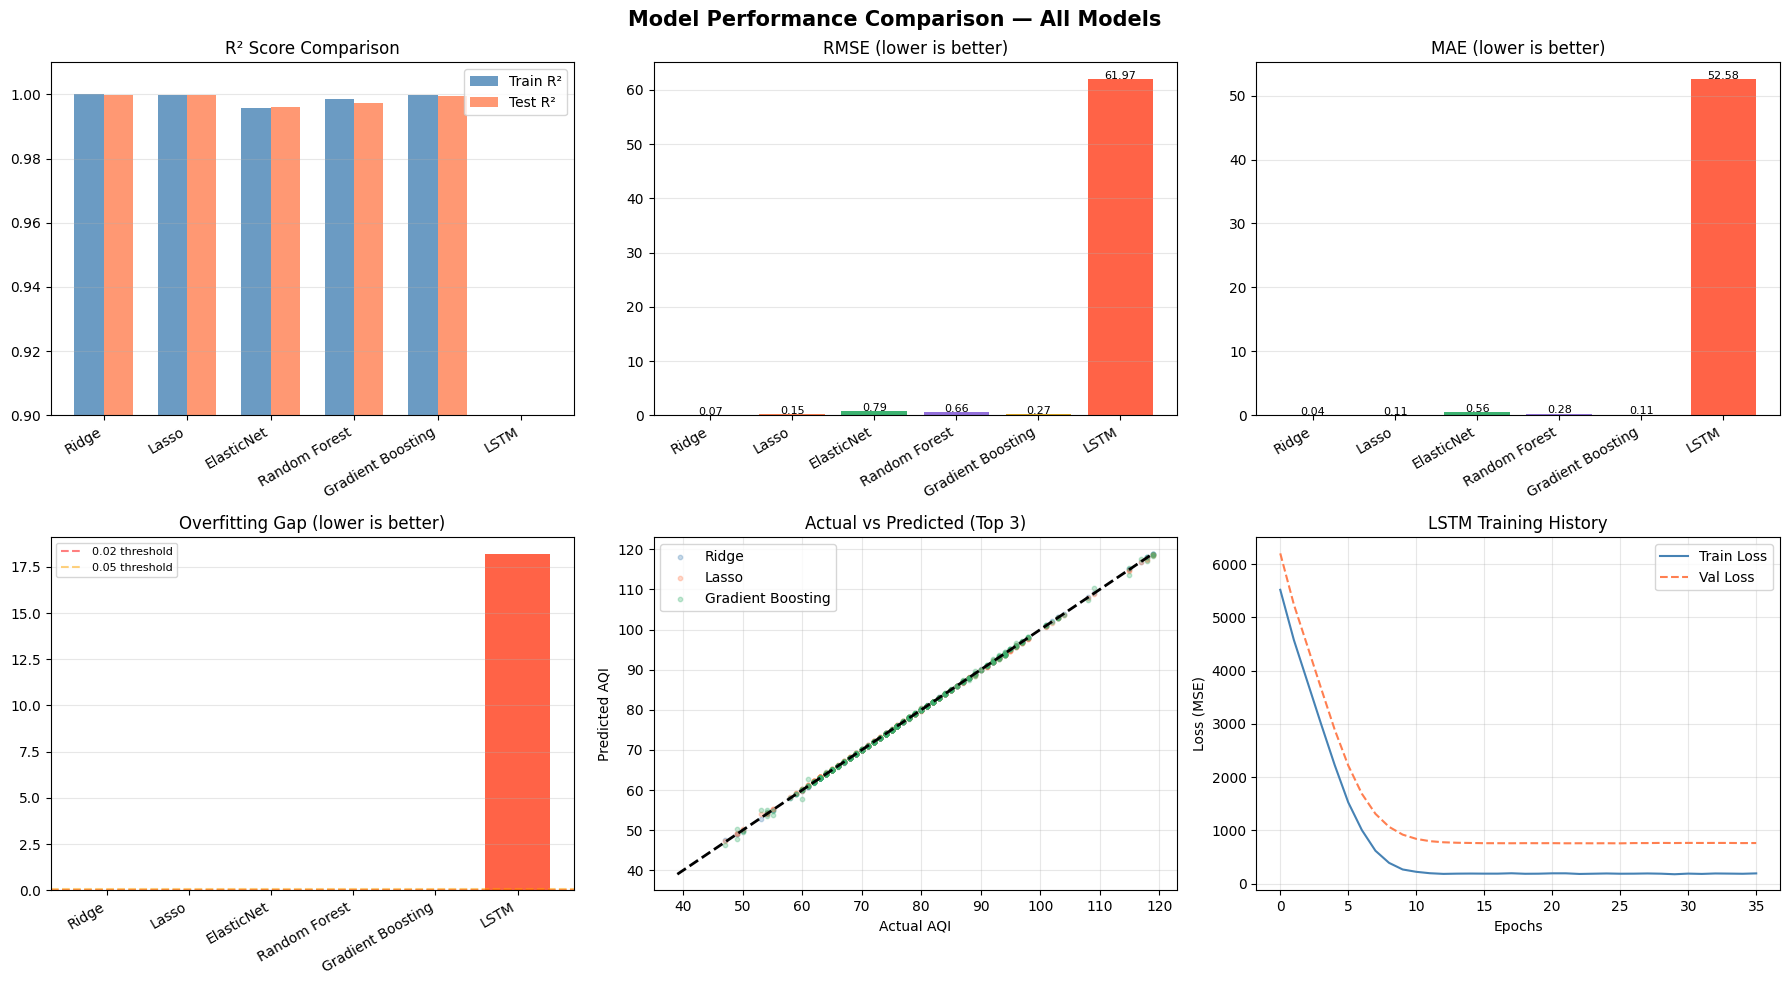

In [14]:
import matplotlib.pyplot as plt

names     = list(results.keys())
test_r2s  = [results[m]["test_r2"]  for m in names]
train_r2s = [results[m]["train_r2"] for m in names]
rmses     = [results[m]["rmse"]     for m in names]
maes      = [results[m]["mae"]      for m in names]
gaps      = [results[m]["gap"]      for m in names]
colors    = ["steelblue", "coral", "mediumseagreen", "mediumpurple", "goldenrod", "tomato", "teal"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Model Performance Comparison — All Models", fontsize=15, fontweight="bold")

x = np.arange(len(names))
w = 0.35

# Plot 1 — Train vs Test R²
axes[0,0].bar(x - w/2, train_r2s, w, label="Train R²", color="steelblue", alpha=0.8)
axes[0,0].bar(x + w/2, test_r2s,  w, label="Test R²",  color="coral",     alpha=0.8)
axes[0,0].set_title("R² Score Comparison")
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(names, rotation=30, ha="right")
axes[0,0].set_ylim(0.9, 1.01)
axes[0,0].legend()
axes[0,0].grid(axis="y", alpha=0.3)

# Plot 2 — RMSE
axes[0,1].bar(names, rmses, color=colors)
axes[0,1].set_title("RMSE (lower is better)")
axes[0,1].set_xticklabels(names, rotation=30, ha="right")
axes[0,1].grid(axis="y", alpha=0.3)
for i, v in enumerate(rmses):
    axes[0,1].text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)

# Plot 3 — MAE
axes[0,2].bar(names, maes, color=colors)
axes[0,2].set_title("MAE (lower is better)")
axes[0,2].set_xticklabels(names, rotation=30, ha="right")
axes[0,2].grid(axis="y", alpha=0.3)
for i, v in enumerate(maes):
    axes[0,2].text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)

# Plot 4 — Overfitting Gap
axes[1,0].bar(names, gaps, color=colors)
axes[1,0].axhline(y=0.02, color="red", linestyle="--", alpha=0.5, label="0.02 threshold")
axes[1,0].axhline(y=0.05, color="orange", linestyle="--", alpha=0.5, label="0.05 threshold")
axes[1,0].set_title("Overfitting Gap (lower is better)")
axes[1,0].set_xticklabels(names, rotation=30, ha="right")
axes[1,0].legend(fontsize=8)
axes[1,0].grid(axis="y", alpha=0.3)

# Plot 5 — Actual vs Predicted (top 3 only)
top3_names = sorted(results.keys(), key=lambda x: results[x]["test_r2"], reverse=True)[:3]
plot_colors = ["steelblue", "coral", "mediumseagreen"]
for name, color in zip(top3_names, plot_colors):
    r = results[name]
    if name == "LSTM":
        y_actual = y_lstm_test
    else:
        y_actual = y_test
    axes[1,1].scatter(y_actual, r["test_preds"], alpha=0.3, s=10, color=color, label=name)
axes[1,1].plot([y.min(), y.max()], [y.min(), y.max()], "k--", lw=2)
axes[1,1].set_title("Actual vs Predicted (Top 3)")
axes[1,1].set_xlabel("Actual AQI")
axes[1,1].set_ylabel("Predicted AQI")
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

# Plot 6 — LSTM training history
axes[1,2].plot(history_lstm.history["loss"],     label="Train Loss", color="steelblue")
axes[1,2].plot(history_lstm.history["val_loss"], label="Val Loss",   color="coral", linestyle="--")
axes[1,2].set_title("LSTM Training History")
axes[1,2].set_xlabel("Epochs")
axes[1,2].set_ylabel("Loss (MSE)")
axes[1,2].legend()
axes[1,2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Cell 14 — Save top 3 models:

In [15]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

top3 = ["Ridge", "Lasso", "Gradient Boosting"]

for name in top3:
    filename = name.lower().replace(" ", "_")
    joblib.dump(results[name]["model"], f"../models/{filename}.pkl")
    print(f"Saved {name} → ../models/{filename}.pkl ✅")

joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(le,     "../models/label_encoder.pkl")
print("Saved scaler and label encoder ✅")

Saved Ridge → ../models/ridge.pkl ✅
Saved Lasso → ../models/lasso.pkl ✅
Saved Gradient Boosting → ../models/gradient_boosting.pkl ✅
Saved scaler and label encoder ✅


### Cell 15 — Save metrics to MongoDB:

In [16]:
from pymongo import MongoClient
import os

client = MongoClient(MONGODB_URI)
db     = client["pearls_aqi"]
col    = db["model_metadata"]
col.drop()

for name in top3:
    r = results[name]
    col.insert_one({
        "model":      name,
        "train_r2":   round(r["train_r2"], 4),
        "test_r2":    round(r["test_r2"],  4),
        "rmse":       round(r["rmse"],     4),
        "mae":        round(r["mae"],      4),
        "trained_at": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S"),
        "status":     "active",
        "is_primary": name == "Ridge"
    })
    print(f"Saved {name} metrics to MongoDB ✅")

client.close()
print("\nAll done! Models saved locally and metrics in MongoDB ✅")

Saved Ridge metrics to MongoDB ✅
Saved Lasso metrics to MongoDB ✅
Saved Gradient Boosting metrics to MongoDB ✅

All done! Models saved locally and metrics in MongoDB ✅
